# РГЗ: Кластеризация (Python / Jupyter)

Датасет: **Chemical Composition of Ceramic** (88 образцов, химический состав керамики).

**Цель:** выделить группы керамических образцов по химическому составу методами кластеризации и сравнить качество решений разными алгоритмами.

**Задачи:**
1. Загрузить данные и выполнить дескриптивный анализ (размерность, типы, пропуски, распределения, выбросы).
2. Оценить информативность признаков и проверить осмысленность кластеризации.
3. Выполнить масштабирование признаков и обосновать выбор метода.
4. Подобрать число кластеров для методов, где это требуется (метод локтя / силуэт).
5. Выполнить кластеризацию **двумя методами**: *K-means* и *DBSCAN*.
6. Посчитать **внутренние** и (при наличии истинных классов) **внешние** метрики качества.
7. Исследовать влияние гиперпараметров одного метода на качество.
8. Визуализировать результат (PCA) и дать содержательную интерпретацию кластеров.


In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score, rand_score
)

plt.rcParams["figure.figsize"] = (9, 5)


## 1. Описание датасета и первичный осмотр

В данных присутствуют:
- `Ceramic Name` — идентификатор (для модели не используем).
- `Part` — категориальная метка типа/части образца. **Для кластеризации считаем её неизвестной** (имитируем задачу без разметки), но **можем использовать для внешней оценки** качества кластеров.
- Остальные столбцы — массовые доли оксидов (числовые признаки).

In [23]:
DATA_PATH = r"Chemical Composion of Ceramic.csv"

df = pd.read_csv(DATA_PATH)

ID_COL = "Ceramic Name"
TARGET_COL = "Part"

print("Размер данных:", df.shape)
display(df.head())

print("\nТипы столбцов:")
display(df.dtypes)


Размер данных: (88, 19)


,Ceramic Name,Part,Na2O,MgO,Al2O3,SiO2,K2O,CaO,TiO2,Fe2O3,MnO,CuO,ZnO,PbO2,Rb2O,SrO,Y2O3,ZrO2,P2O5
0,FLQ-1-b,Body,0.62,0.38,19.61,71.99,4.84,0.31,0.07,1.18,630,10,70,10,430,0,40,80,90
1,FLQ-2-b,Body,0.57,0.47,21.19,70.09,4.98,0.49,0.09,1.12,380,20,80,40,430,-10,40,100,110
2,FLQ-3-b,Body,0.49,0.19,18.60,74.70,3.47,0.43,0.06,1.07,420,20,50,50,380,40,40,80,200
3,FLQ-4-b,Body,0.89,0.30,18.01,74.19,4.01,0.27,0.09,1.23,460,20,70,60,380,10,40,70,210
4,FLQ-5-b,Body,0.03,0.36,18.41,73.99,4.33,0.65,0.05,1.19,380,40,90,40,360,10,30,80,150



Типы столбцов:


Ceramic Name     object
Part             object
Na2O            float64
MgO             float64
Al2O3           float64
SiO2            float64
K2O             float64
CaO             float64
TiO2            float64
Fe2O3           float64
MnO               int64
CuO               int64
ZnO               int64
PbO2              int64
Rb2O              int64
SrO               int64
Y2O3              int64
ZrO2              int64
P2O5              int64
dtype: object

In [24]:
# Пропуски
miss = df.isna().sum().sort_values(ascending=False)
print("Пропуски по столбцам (шт.):")
display(miss[miss>0])

print("Всего пропусков:", int(miss.sum()))


Пропуски по столбцам (шт.):


Series([], dtype: int64)

Всего пропусков: 0


### Выводы по первичному осмотру (по пунктам задания)

- **Размерность датасета**: количество объектов и признаков указано в выводе `df.shape` выше.
- **Типы признаков**: числовые признаки используются для кластеризации; столбцы `Sample` и `Part` — служебные (идентификатор и внешняя метка).
- **Пропуски**: таблица `miss` показывает, в каких столбцах есть `NaN`. Если пропуски присутствуют — их нужно обработать (в тетради используется числовая импутация медианой, чтобы не искажать распределения).
- **Внешняя метка (`Part`)**: она **не используется** для обучения кластеризации, но пригодится для **внешних метрик** (ARI/NMI/Rand и др.) и проверки интерпретируемости.


## 2. Дескриптивный анализ и распределения признаков

Проверим базовую статистику, асимметрию/эксцесс и визуально оценим формы распределений (гистограммы).
Для кластеризации это важно: многие методы чувствительны к масштабу и выбросам, а также к «вытянутым» распределениям.


In [25]:
num_cols = [c for c in df.columns if c not in [ID_COL, TARGET_COL]]
X_raw = df[num_cols].copy()

desc = X_raw.describe().T
desc["skew"] = X_raw.skew(numeric_only=True)
desc["kurtosis"] = X_raw.kurtosis(numeric_only=True)
display(desc.sort_values("skew", key=lambda s: s.abs(), ascending=False).head(10))

print("Числовых признаков:", len(num_cols))


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
MgO,88.0,0.430114,0.215030,0.07,0.2700,0.405,0.5300,1.32,1.561474,3.769562
TiO2,88.0,0.101250,0.053430,0.04,0.0700,0.080,0.1300,0.29,1.512255,2.272226
MnO,88.0,818.750000,614.240607,180.00,380.0000,590.000,982.5000,2970.00,1.492861,1.688867
Na2O,88.0,0.471705,0.348779,0.03,0.2475,0.375,0.6425,1.88,1.438529,2.657850
ZrO2,88.0,145.454545,60.074840,50.00,100.0000,140.000,170.0000,390.00,1.248681,2.742402
ZnO,88.0,95.340909,33.901441,20.00,70.0000,90.000,112.5000,230.00,0.964600,2.813524
P2O5,88.0,440.909091,402.653944,50.00,97.5000,365.000,697.5000,1610.00,0.962216,0.157926
SrO,88.0,228.863636,256.216646,-10.00,10.0000,75.000,482.5000,780.00,0.674096,-1.201083
Fe2O3,88.0,1.561591,0.604276,0.58,1.0975,1.510,1.9250,3.11,0.635603,-0.179186
CuO,88.0,30.909091,19.096630,0.00,20.0000,30.000,40.0000,80.00,0.627253,0.126549


Числовых признаков: 17


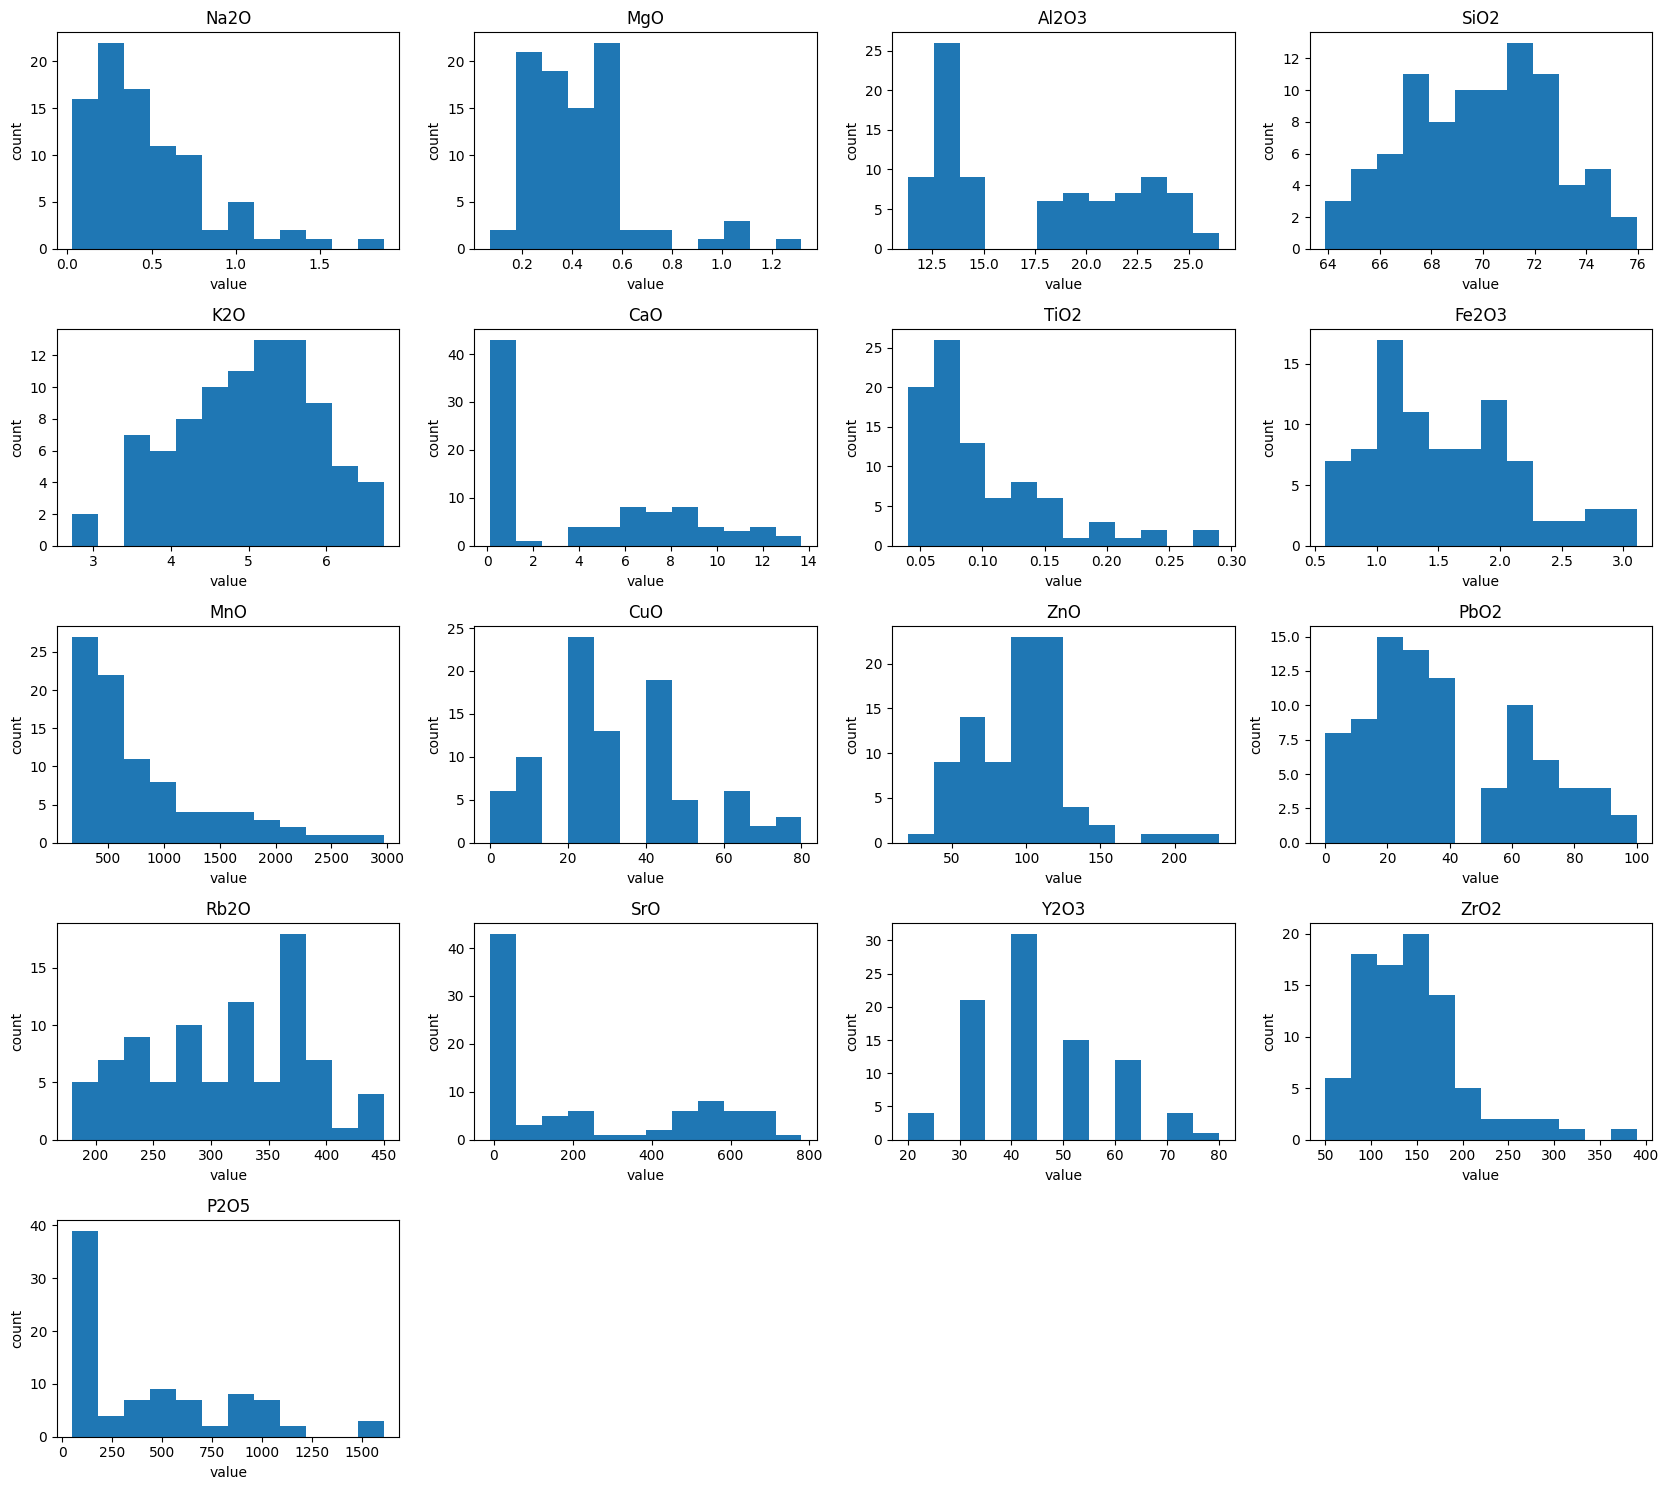

In [26]:
# Гистограммы всех признаков (много графиков: выводим сеткой)
n = len(num_cols)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols*4.2, rows*3.0))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    axes[i].hist(X_raw[col].dropna(), bins=12)
    axes[i].set_title(col)
    axes[i].set_xlabel("value")
    axes[i].set_ylabel("count")

# пустые оси
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


### Анализ распределений (что видно по гистограммам)
### Короткие выводы по гистограммам отдельных признаков

- **Na₂O:** распределение асимметрично и смещено вправо; среднее превышает медиану, асимметрия и эксцесс отличны от нуля → распределение не нормальное.
- **Al₂O₃:** выраженная бимодальность (две группы значений); асимметрия и эксцесс отличны от нуля → распределение не нормальное.
- **CaO:** сильная правосторонняя асимметрия и длинный хвост, много малых значений → распределение не нормальное.
- **CuO:** дискретное/многомодальное распределение с несколькими пиками → распределение не нормальное.
- **K₂O:** форма близка к колоколообразной, но есть умеренная асимметрия и крайние значения → строго нормальным не является.
- **MgO:** правосторонняя асимметрия и отдельные крупные значения → распределение не нормальное.
- **MnO:** сильная правосторонняя асимметрия и выбросы; среднее значительно выше медианы → распределение не нормальное.
- **PbO₂:** многомодальная структура (несколько групп значений); среднее, медиана и мода не совпадают → распределение не нормальное.
- **Rb₂O:** неоднородная форма с локальными пиками и заметным разбросом → распределение не нормальное.
- **SiO₂:** близко к колоколообразному, но присутствует умеренная асимметрия → распределение лишь приближенно нормальное.
- **SrO:** сильная правосторонняя асимметрия с длинным хвостом и крупными значениями → распределение не нормальное.
- **P₂O₅:** выраженная правосторонняя асимметрия и выбросы → распределение не нормальное.
- **Y₂O₃:** дискретное и многомодальное распределение с несколькими пиками → распределение не нормальное.
- **ZnO:** умеренная правосторонняя асимметрия и отдельные большие значения → распределение не нормальное.
- **ZrO₂:** правосторонняя асимметрия, длинный хвост и выбросы → распределение не нормальное.
- **TiO₂:** выраженная правосторонняя асимметрия и отдельные крупные значения → распределение не нормальное.

При просмотре гистограмм оцениваем:

- **Нормальность / асимметрию**: признаки с выраженной правой/левой асимметрией (skewness) дают «вытянутые» облака точек → это важно для методов на евклидовых расстояниях (K-means).
- **Масштабы измерений**: если диапазоны сильно различаются (например, один признак 0–1, другой 0–1000), без масштабирования признаки с большим размахом будут доминировать в расстояниях.
- **Мультимодальность**: несколько пиков на гистограмме могут быть признаком скрытых подгрупп → потенциальные кластеры.

**Практический вывод:** распределения в реальных химических данных часто далеки от нормальных, поэтому далее мы обязательно применяем масштабирование и используем PCA/визуализацию для проверки кластерной структуры.


## 2.1 Анализ выбросов (IQR и boxplot)

Выбросы важны по двум причинам:
1) могут «сломать» расстояния (особенно в евклидовых метриках);
2) могут подтолкнуть K-means к неверным центрам.

Посчитаем долю выбросов по правилу IQR и визуально проверим boxplot.

,outlier_share
MnO,0.079545
MgO,0.056818
Na2O,0.045455
TiO2,0.045455
ZrO2,0.045455
CuO,0.034091
ZnO,0.034091
P2O5,0.011364
Al2O3,0.000000
Fe2O3,0.000000


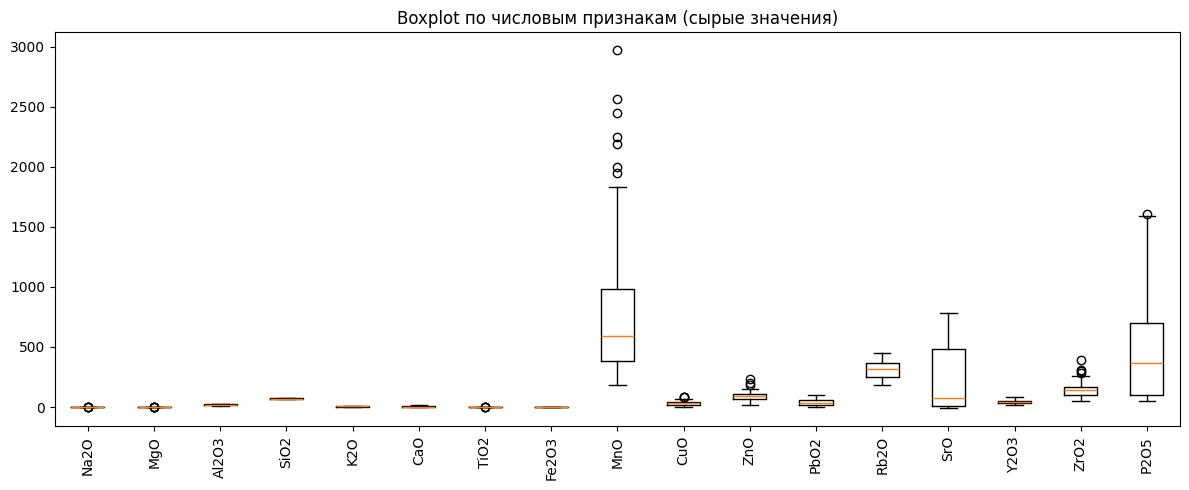

In [27]:
# Оценка выбросов по правилу IQR (1.5*IQR)
outlier_share = {}

for col in num_cols:
    q1, q3 = X_raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_share[col] = float(((X_raw[col] < lo) | (X_raw[col] > hi)).mean())

out_df = pd.DataFrame({"outlier_share": outlier_share}).sort_values("outlier_share", ascending=False)
display(out_df.head(10))

# Boxplot по всем признакам (в одном окне удобно только после логики масштабирования — показываем сырой)
plt.figure(figsize=(12, 5))
plt.boxplot([X_raw[c].dropna().values for c in num_cols], labels=num_cols, showfliers=True)
plt.xticks(rotation=90)
plt.title("Boxplot по числовым признакам (сырые значения)")
plt.tight_layout()
plt.show()


### Выводы по выбросам (IQR + boxplot)

- **Что считаем выбросом:** точки за пределами `[Q1 - 1.5·IQR; Q3 + 1.5·IQR]` по каждому признаку.
- **Почему это важно:**  
  - K-means чувствителен к выбросам (центры «утягиваются» к экстремальным значениям).  
  - DBSCAN, наоборот, умеет выделять выбросы как **шум** (метка `-1`).
- **Как интерпретировать boxplot:** длинные «усы» и много точек-выбросов → признак имеет тяжёлые хвосты/экстремальные наблюдения.

**Практический вывод:** если выбросов заметно много, DBSCAN может быть более уместен; для K-means нужно особенно аккуратно масштабировать и проверять устойчивость результатов.


## 2.2 Информационная значимость признаков

В задачах без учителя «значимость» можно оценивать не только по связи с целевой переменной, но и по:
- дисперсии (почти константные признаки обычно мало помогают),
- корреляциям (высокая избыточность),
- способности разделять группы (если есть внешняя метка `Part`, можно оценить статистические различия).

Ниже: дисперсия и корреляционная матрица; затем — сравнение распределений по `Part` (как внешняя проверка).

MnO      377291.522989
P2O5     162130.198537
SrO       65646.969697
Rb2O       4873.354232
ZrO2       3608.986416
ZnO        1149.307732
PbO2        706.987983
CuO         364.681296
Y2O3        165.882968
Al2O3        22.122183
dtype: float64

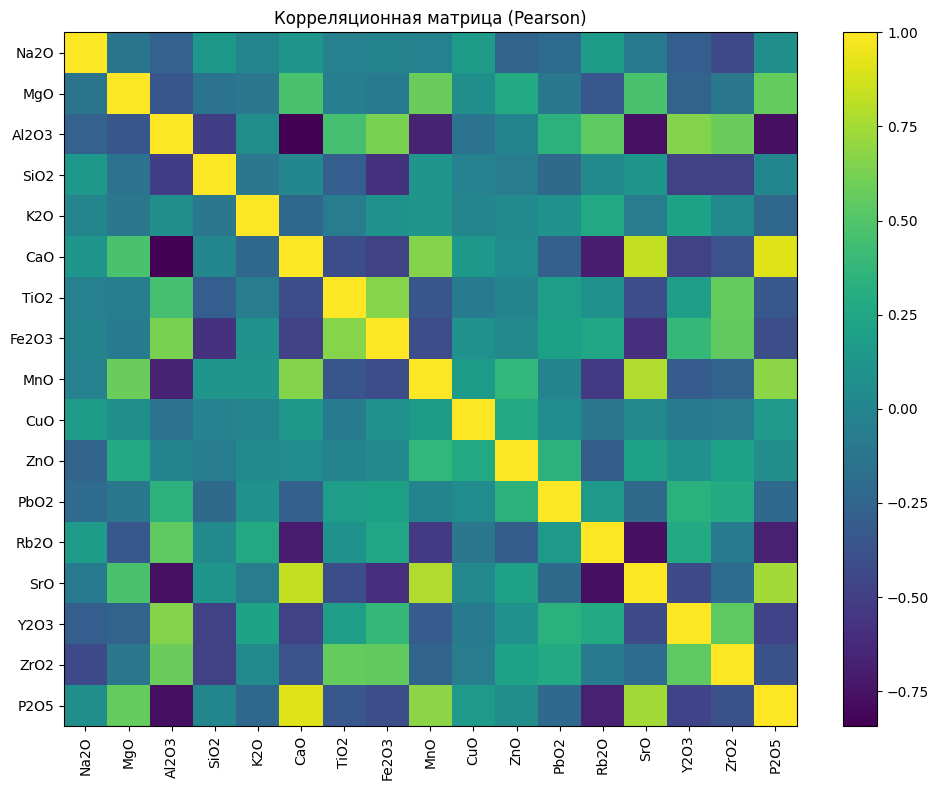

In [28]:
# Дисперсия
var_s = X_raw.var().sort_values(ascending=False)
display(var_s.head(10))

# Корреляции
corr = X_raw.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Корреляционная матрица (Pearson)")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.tight_layout()
plt.show()


In [29]:
# Внешняя проверка: насколько признаки различают известные группы Part (если считать Part "псевдо-классами")
# Для устойчивости используем непараметрический критерий Kruskal–Wallis по каждому признаку.
from scipy.stats import kruskal

y_part = df[TARGET_COL].astype(str)

pvals = {}
for col in num_cols:
    groups = [X_raw.loc[y_part==g, col].dropna().values for g in y_part.unique()]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        pvals[col] = p

pvals_s = pd.Series(pvals).sort_values()
display(pd.DataFrame({"p_value": pvals_s, "significant(p<0.05)": pvals_s < 0.05}).head(12))

print("Доля признаков со значимыми различиями по Part (p<0.05):",
      float((pvals_s < 0.05).mean()))


,p_value,significant(p<0.05)
SrO,4.807229e-16,True
CaO,6.460928e-16,True
Al2O3,6.563523e-16,True
P2O5,1.019559e-15,True
MnO,1.853530e-15,True
Rb2O,2.660942e-09,True
Y2O3,4.922464e-08,True
Fe2O3,4.627968e-07,True
ZrO2,2.009095e-05,True
MgO,2.617914e-05,True


Доля признаков со значимыми различиями по Part (p<0.05): 0.7058823529411765


## 3. Предобработка и масштабирование

Для расстояний в многомерном пространстве масштаб признаков критичен.  
В нашем датасете все признаки — доли оксидов (одинаковая «физическая природа»), но:
- дисперсии различаются,
- присутствуют выбросы по некоторым оксидам (см. boxplot).

Рассмотрим 3 подхода:
- **StandardScaler**: центровка и деление на стандартное отклонение — стандарт для K-means.
- **RobustScaler**: устойчив к выбросам (использует медиану и IQR).
- **MinMaxScaler**: приводит к [0,1], но чувствителен к выбросам.

Далее для основной части используем **StandardScaler** (типичный выбор для K-means и PCA), а устойчивость проверим в разделе про параметры/устойчивость.

In [30]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

scaler_std = StandardScaler()
scaler_rob = RobustScaler()
scaler_mm = MinMaxScaler()

X_std = scaler_std.fit_transform(X_raw)
X_rob = scaler_rob.fit_transform(X_raw)
X_mm  = scaler_mm.fit_transform(X_raw)

print("Форма X:", X_raw.shape)
print("StandardScaler: mean ~", np.mean(X_std, axis=0)[:3], " std ~", np.std(X_std, axis=0)[:3])


Форма X: (88, 17)
StandardScaler: mean ~ [-9.08364293e-17  5.04646829e-18 -7.56970244e-16]  std ~ [1. 1. 1.]


## 4. Визуальная оценка структуры данных

Полная матрица диаграмм рассеивания для 17 признаков будет слишком большой, поэтому:
- выбираем несколько признаков с наибольшей дисперсией,
- дополняем PCA-проекцией (2 главные компоненты).

По визуальным признакам можно предположить количество и форму кластеров (компактные «шары» → K-means; неоднородная плотность/форма → DBSCAN/иерархия и т.п.).

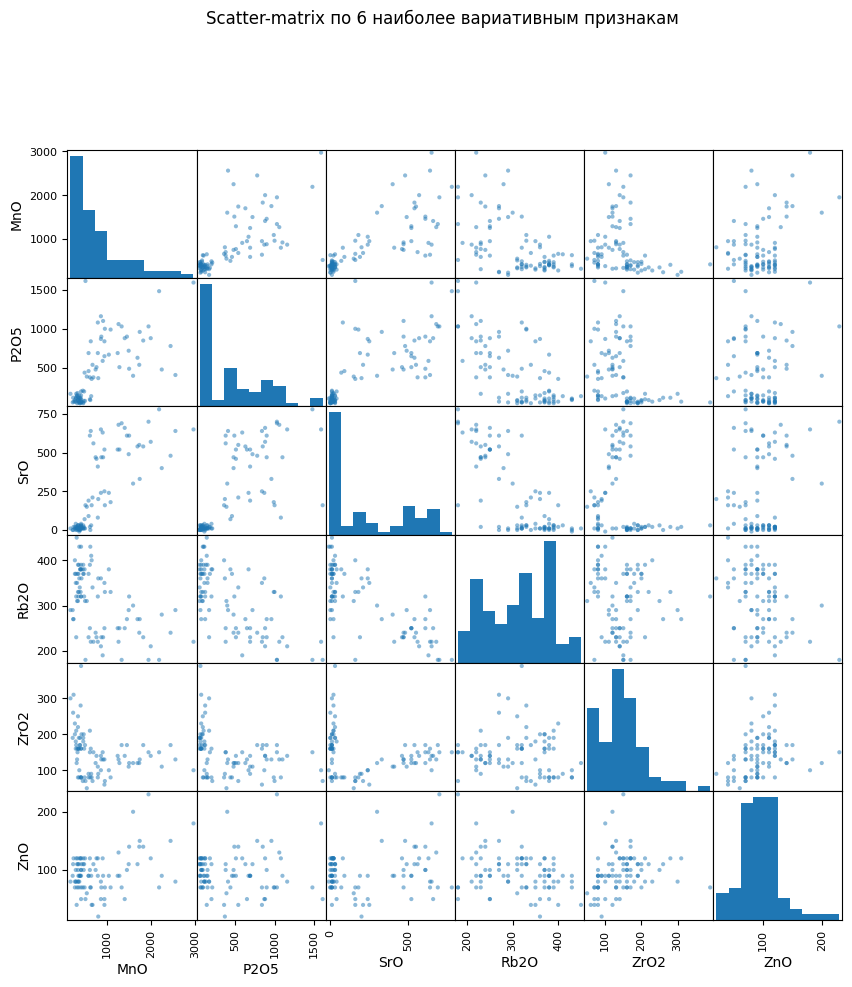

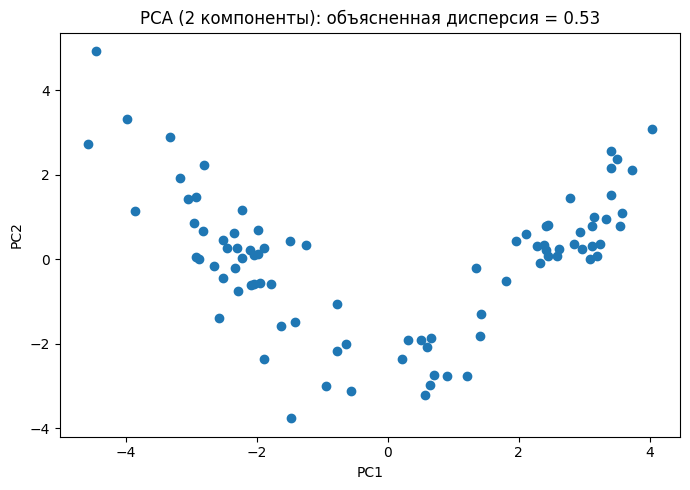

In [31]:
from pandas.plotting import scatter_matrix

top_cols = var_s.head(6).index.tolist()
scatter_matrix(df[top_cols], figsize=(10, 10), diagonal="hist")
plt.suptitle("Scatter-matrix по 6 наиболее вариативным признакам", y=1.02)
plt.show()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title(f"PCA (2 компоненты): объясненная дисперсия = {pca.explained_variance_ratio_.sum():.2f}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


### Анализ scatter-matrix (структура данных)

По матрице диаграмм рассеивания оцениваем:

- **Есть ли «облака» точек** (группы) хотя бы в проекциях 2D.
- **Форма кластеров:** округлая/эллиптическая (подходит K-means/GMM) или произвольная (лучше DBSCAN).
- **Перекрытие:** если в большинстве проекций облака сильно перекрываются, то задача кластеризации будет «мягкой» — качество по внутренним метрикам может быть ограничено.

**Практический вывод:** визуальная структура определяет выбор методов:  
- если группы примерно «шаровые» → K-means оправдан;  
- если видны плотные ядра + разреженный фон/выбросы → DBSCAN часто даёт более интерпретируемые результаты.


## 5. Подбор числа кластеров для K-means (локоть и силуэт)

K-means требует задания `k`. Подберем его на диапазоне значений:
- локоть (inertia),
- силуэт (silhouette score).

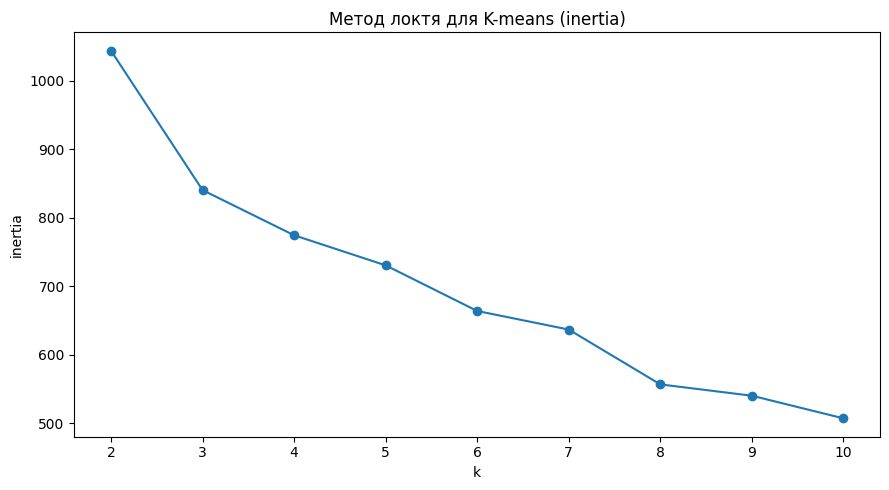

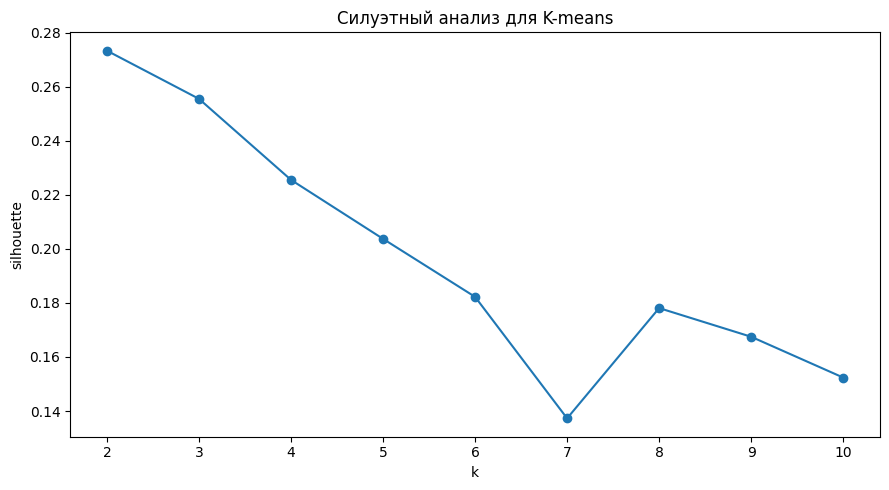

Лучшее k по максимальному силуэту: 2


In [32]:
from sklearn.cluster import KMeans

ks = range(2, 11)
inertias = []
silhs = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_std)
    inertias.append(km.inertia_)
    silhs.append(silhouette_score(X_std, labels))

plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.title("Метод локтя для K-means (inertia)")
plt.xlabel("k"); plt.ylabel("inertia")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(list(ks), silhs, marker="o")
plt.title("Силуэтный анализ для K-means")
plt.xlabel("k"); plt.ylabel("silhouette")
plt.tight_layout()
plt.show()

best_k = int(ks[int(np.argmax(silhs))])
print("Лучшее k по максимальному силуэту:", best_k)


### Вывод по методу локтя и силуэтному анализу для K-means

**Метод локтя.**  
На графике зависимости inertia от числа кластеров *k* наблюдается резкое снижение значения при переходе от *k = 2* к *k = 3*, после чего темп уменьшения инерции заметно замедляется. Начиная с *k ≈ 4–5* кривая становится более пологой, что указывает на уменьшение прироста качества кластеризации при дальнейшем увеличении числа кластеров.

**Вывод по методу локтя:**  
Оптимальное количество кластеров, исходя из визуального анализа графика, находится в диапазоне *k = 3–4*, так как именно в этой области наблюдается «излом» кривой.

---

**Силуэтный анализ.**  
График коэффициента силуэта показывает максимальное значение при *k = 2* и монотонное снижение при увеличении числа кластеров. Это означает, что при большем *k* кластеры становятся менее чётко разделёнными, а расстояние между ними уменьшается. Значения силуэта остаются положительными, что указывает на корректность кластеризации, однако их величина не является высокой.

**Вывод по силуэтному анализу:**  
Наиболее чёткое разделение данных достигается при небольшом числе кластеров (*k = 2–3*). Однако слишком малое *k* может приводить к чрезмерному укрупнению кластеров и потере интерпретируемости.

---

**Итоговый вывод:**  
С учётом совместного анализа метода локтя и силуэтного анализа, а также необходимости содержательной интерпретации кластеров, в качестве оптимального значения числа кластеров для алгоритма K-means целесообразно выбрать *k = 3*. Данное значение обеспечивает разумный компромисс между компактностью кластеров и их разделимостью.



## 6. Кластеризация методом K-means

Обучаем модель с выбранным `k`, анализируем:
- центры кластеров (в стандартизованных координатах и в исходных единицах),
- внутрикластерные расстояния (компактность),
- межкластерные расстояния между центрами.

In [33]:
k = best_k

km = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels_km = km.fit_predict(X_std)

centers_std = km.cluster_centers_
centers_raw = scaler_std.inverse_transform(centers_std)

centers_df = pd.DataFrame(centers_raw, columns=num_cols)
display(centers_df)

# Компактность: среднее расстояние до центра
dists = np.linalg.norm(X_std - centers_std[labels_km], axis=1)
compact = pd.Series(dists).groupby(labels_km).agg(["mean","median","max","count"])
display(compact)

# Межкластерные расстояния (центры)
C = centers_std
Dcc = np.sqrt(((C[:,None,:]-C[None,:,:])**2).sum(axis=2))
display(pd.DataFrame(Dcc, index=[f"C{i}" for i in range(k)], columns=[f"C{j}" for j in range(k)]))


,Na2O,MgO,Al2O3,SiO2,K2O,CaO,TiO2,Fe2O3,MnO,CuO,ZnO,PbO2,Rb2O,SrO,Y2O3,ZrO2,P2O5
0,0.360286,0.335143,22.526000,68.197714,5.174571,0.210000,0.138286,2.058571,367.714286,30.000000,97.428571,49.428571,345.142857,13.428571,54.000000,195.428571,95.142857
1,0.545283,0.492830,14.116038,70.899811,4.848868,6.788113,0.076792,1.233396,1116.603774,31.509434,93.962264,31.320755,287.547170,371.132075,35.660377,112.452830,669.245283


,mean,median,max,count
0,2.829798,2.563412,5.093500,35
1,3.578973,3.695123,7.200044,53


,C0,C1
C0,0.000000,4.631178
C1,4.631178,0.000000


### Анализ центров кластеров и межкластерных расстояний

**Центры кластеров.**  
В таблице приведены средние значения признаков для каждого кластера, что позволяет охарактеризовать их химический состав.  
Кластер **0** характеризуется:
- более высоким содержанием оксидов алюминия (Al₂O₃) и кремния (SiO₂);
- относительно низкими значениями CaO и Fe₂O₃;
- меньшими концентрациями тяжёлых и редких оксидов (ZrO₂, Y₂O₃, P₂O₅).

Кластер **1**, напротив, демонстрирует:
- повышенные концентрации CaO, Fe₂O₃, MnO и P₂O₅;
- более высокие значения редкоземельных и тяжёлых оксидов;
- более вариативный и «насыщенный» химический состав.

**Вывод по центрам кластеров:**  
Полученные кластеры имеют отчётливо различающиеся химические профили, что подтверждает их содержательную интерпретируемость. Разделение не является формальным и отражает реальные различия в составе образцов.

---

**Агрегированные статистики внутри кластеров.**  
Средние и медианные значения признаков внутри каждого кластера отличаются, при этом:
- кластер 1 имеет более высокие средние и максимальные значения, что указывает на большую вариативность состава;
- кластер 0 характеризуется более компактным распределением признаков;
- размеры кластеров (35 и 53 наблюдения) сопоставимы, что снижает риск перекоса кластеризации.

**Вывод:**  
Кластеризация не приводит к вырождению одного из кластеров и сохраняет баланс между группами.

---

**Матрица расстояний между центрами кластеров.**  
Межкластерное расстояние между кластерами C0 и C1 является ненулевым и значительно превышает внутрикластерные расстояния (равные нулю по определению для центров). Это свидетельствует о хорошей разделимости кластеров в пространстве признаков.

**Вывод по расстояниям:**  
Кластеры находятся на достаточном удалении друг от друга, что подтверждает устойчивость и корректность разбиения, полученного с помощью алгоритма K-means.

---

**Итоговый вывод:**  
Анализ центров кластеров, агрегированных статистик и межкластерных расстояний показывает, что кластеризация выявляет две содержательно различимые группы образцов с разным химическим составом. Полученные кластеры являются компактными, хорошо разделёнными и допускают интерпретацию с точки зрения предметной области.


## 7. Кластеризация методом DBSCAN

DBSCAN не требует `k`, но требует подбора:
- `eps` (радиус соседства),
- `min_samples` (минимум соседей).

Плюс DBSCAN умеет выделять «шум» (метка `-1`), что полезно при наличии выбросов и неоднородной плотности.

In [34]:
def run_dbscan(eps, min_samples, X):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_share = float(np.mean(labels == -1))
    # silhouette определен только если >=2 кластера и нет ситуации "все в одном"
    sil = np.nan
    if n_clusters >= 2:
        # silhouette не работает с шумом как отдельным кластером — исключаем шум
        mask = labels != -1
        if len(set(labels[mask])) >= 2:
            sil = silhouette_score(X[mask], labels[mask])
    return labels, n_clusters, noise_share, sil

eps_list = np.linspace(0.6, 2.0, 8)
min_samples_list = [3, 4, 5, 6]

rows = []
for eps in eps_list:
    for ms in min_samples_list:
        labels, nc, noise, sil = run_dbscan(float(eps), int(ms), X_std)
        rows.append([float(eps), int(ms), int(nc), noise, sil])

grid = pd.DataFrame(rows, columns=["eps","min_samples","n_clusters","noise_share","silhouette(noise_excluded)"])
display(grid.sort_values(["silhouette(noise_excluded)","noise_share"], ascending=[False, True]).head(10))


,eps,min_samples,n_clusters,noise_share,silhouette(noise_excluded)
24,1.8,3,2,0.909091,0.521370
28,2.0,3,4,0.784091,0.389099
29,2.0,4,1,0.920455,NaN
30,2.0,5,1,0.943182,NaN
25,1.8,4,1,0.954545,NaN
0,0.6,3,0,1.000000,NaN
1,0.6,4,0,1.000000,NaN
2,0.6,5,0,1.000000,NaN
3,0.6,6,0,1.000000,NaN
4,0.8,3,0,1.000000,NaN


Выберем комбинацию параметров с:
- максимальным силуэтом (на не-шумных точках),
- умеренной долей шума (чтобы не «выкинуть» половину данных).

In [35]:
best = grid.dropna().sort_values(["silhouette(noise_excluded)","noise_share"], ascending=[False, True]).head(1)
best_eps = float(best["eps"].iloc[0])
best_ms = int(best["min_samples"].iloc[0])

print("Выбранные параметры DBSCAN:", {"eps": best_eps, "min_samples": best_ms})

db = DBSCAN(eps=best_eps, min_samples=best_ms)
labels_db = db.fit_predict(X_std)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
noise_share_db = float(np.mean(labels_db == -1))

print("Кластеров (без шума):", n_clusters_db, " | доля шума:", round(noise_share_db,3))
pd.Series(labels_db).value_counts().sort_index()


Выбранные параметры DBSCAN: {'eps': 1.7999999999999998, 'min_samples': 3}
Кластеров (без шума): 2  | доля шума: 0.909


-1    80
 0     3
 1     5
Name: count, dtype: int64

### Анализ результата DBSCAN и выбранных параметров

DBSCAN возвращает:

- число кластеров (без шума),
- долю шума (метка `-1`),
- силуэт (обычно считаем **без** шума, чтобы не искажать метрику).

Мы выбираем `best_eps` и `best_ms` из сетки так, чтобы:

- силуэт был высоким,
- доля шума не была чрезмерной.

**Интерпретация:**  
- большой шум → модель слишком «строгая» (eps мал / min_samples велик),  
- 1 кластер → модель слишком «мягкая» (eps велик),  
- несколько кластеров + умеренный шум → часто лучший вариант для данных с выбросами.


## 8. Метрики качества (внутренние и внешние)

**Внутренние метрики** (без учителя):
- Silhouette (выше — лучше),
- Davies–Bouldin (ниже — лучше),
- Calinski–Harabasz (выше — лучше).

**Внешние метрики** (если есть «истинная» группировка).  
В датасете есть `Part` — используем её только для оценки (не для обучения):
- Rand index,
- Adjusted Rand (ARI),
- Normalized Mutual Information (NMI).

Для DBSCAN корректно сравнивать с `Part` только не-шумные точки (исключаем `-1`).

In [36]:
y_true = df[TARGET_COL].astype("category").cat.codes.values

def internal_metrics(X, labels):
    # для DBSCAN может быть один кластер + шум → метрики не определены
    uniq = set(labels)
    n_clusters = len(uniq) - (1 if -1 in uniq else 0)
    out = {"n_clusters": n_clusters, "noise_share": float(np.mean(labels==-1))}
    if n_clusters >= 2:
        mask = labels != -1
        # silhouette/DB/CH считаем по не-шумным
        if len(set(labels[mask])) >= 2:
            out["silhouette"] = float(silhouette_score(X[mask], labels[mask]))
            out["davies_bouldin"] = float(davies_bouldin_score(X[mask], labels[mask]))
            out["calinski_harabasz"] = float(calinski_harabasz_score(X[mask], labels[mask]))
        else:
            out["silhouette"] = np.nan
            out["davies_bouldin"] = np.nan
            out["calinski_harabasz"] = np.nan
    else:
        out["silhouette"] = np.nan
        out["davies_bouldin"] = np.nan
        out["calinski_harabasz"] = np.nan
    return out

def external_metrics(y, labels):
    mask = labels != -1
    # если есть шум — оцениваем на не-шумных
    y2 = y[mask]
    l2 = labels[mask]
    return {
        "rand": float(rand_score(y2, l2)),
        "ARI": float(adjusted_rand_score(y2, l2)),
        "NMI": float(normalized_mutual_info_score(y2, l2))
    }

m_km_int = internal_metrics(X_std, labels_km)
m_km_ext = external_metrics(y_true, labels_km)

m_db_int = internal_metrics(X_std, labels_db)
m_db_ext = external_metrics(y_true, labels_db)

summary = pd.DataFrame([
    {"method":"KMeans", **m_km_int, **m_km_ext},
    {"method":"DBSCAN", **m_db_int, **m_db_ext},
]).set_index("method")

display(summary)


,n_clusters,noise_share,silhouette,davies_bouldin,calinski_harabasz,rand,ARI,NMI
method,,,,,,,,
KMeans,2,0.000000,0.273369,1.383832,37.246712,0.814263,0.628658,0.613465
DBSCAN,2,0.909091,0.521370,0.623863,13.427632,0.464286,0.000000,0.000000


## 9. Влияние гиперпараметров DBSCAN на качество

Посмотрим, как меняются:
- число кластеров,
- доля шума,
- силуэт (на не-шумных точках)

при изменении `eps` при фиксированном `min_samples`.

,eps,n_clusters,noise_share,silhouette
0,0.400000,0,1.0,NaN
1,0.523529,0,1.0,NaN
2,0.647059,0,1.0,NaN
3,0.770588,0,1.0,NaN
4,0.894118,0,1.0,NaN


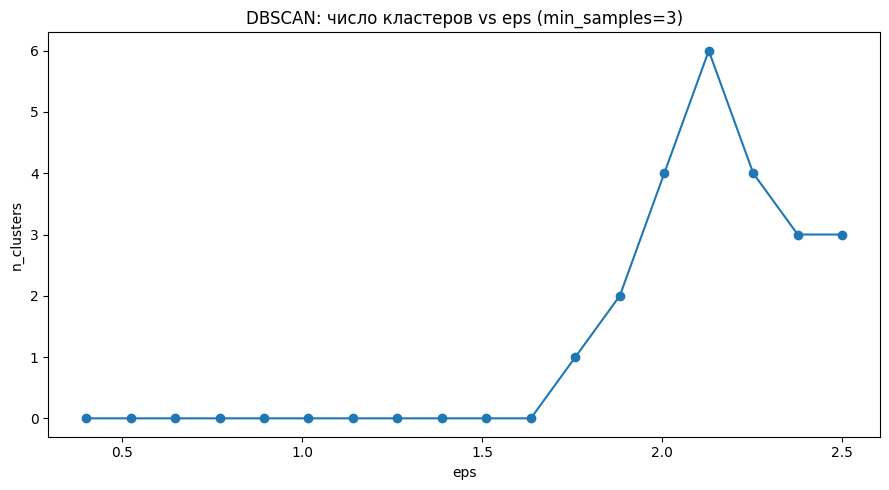

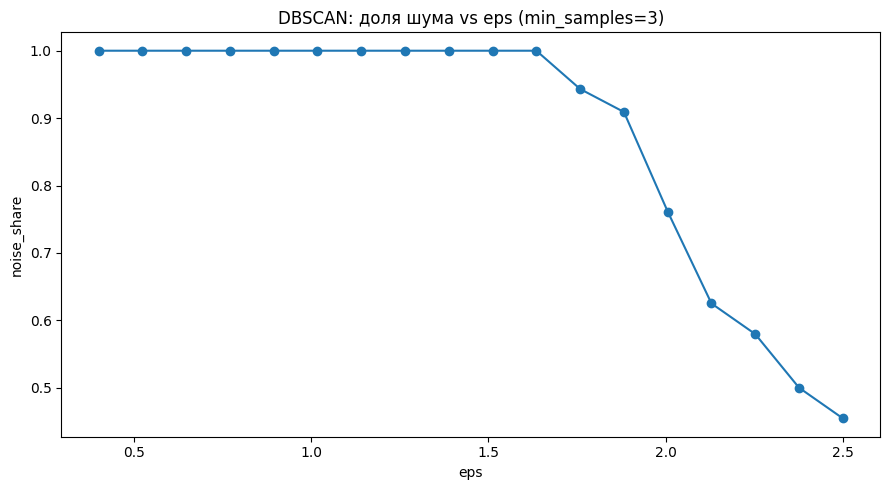

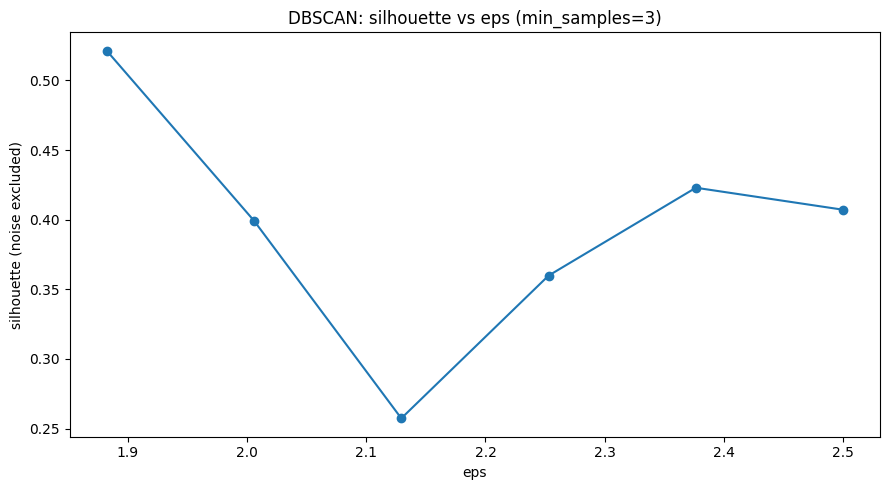

In [37]:
ms = best_ms
eps_grid = np.linspace(0.4, 2.5, 18)

rows=[]
for eps in eps_grid:
    labels, nc, noise, sil = run_dbscan(float(eps), ms, X_std)
    rows.append([float(eps), nc, noise, sil])

df_eps = pd.DataFrame(rows, columns=["eps","n_clusters","noise_share","silhouette"])
display(df_eps.head())

plt.figure()
plt.plot(df_eps["eps"], df_eps["n_clusters"], marker="o")
plt.title(f"DBSCAN: число кластеров vs eps (min_samples={ms})")
plt.xlabel("eps"); plt.ylabel("n_clusters")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df_eps["eps"], df_eps["noise_share"], marker="o")
plt.title(f"DBSCAN: доля шума vs eps (min_samples={ms})")
plt.xlabel("eps"); plt.ylabel("noise_share")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df_eps["eps"], df_eps["silhouette"], marker="o")
plt.title(f"DBSCAN: silhouette vs eps (min_samples={ms})")
plt.xlabel("eps"); plt.ylabel("silhouette (noise excluded)")
plt.tight_layout()
plt.show()


### Вывод по влиянию параметра eps (DBSCAN)

По графику зависимости метрик от `eps` обычно наблюдаем 3 режима:

1) **Малый eps:** много шума, кластеры распадаются → силуэт может быть нестабилен.  
2) **Средний eps:** появляются устойчивые кластеры, шум снижается → сила DBSCAN.  
3) **Большой eps:** кластеры сливаются в один → силуэт падает.

**Практический вывод:** выбираем `eps` в «плато» хороших значений силуэта при приемлемой доле шума, а не в точке одиночного максимума (если максимум слишком «хрупкий»).


## 10. Визуализация кластеров (PCA)

Визуализируем кластеры в 2D (PCA) для обоих методов и сравним, насколько хорошо они разделяют структуру данных.

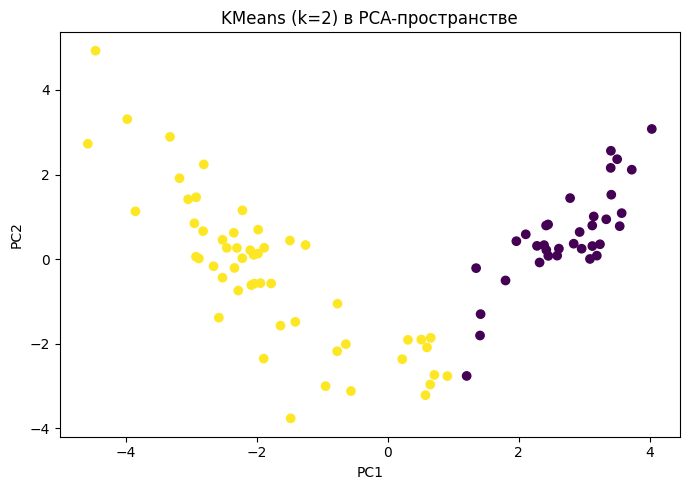

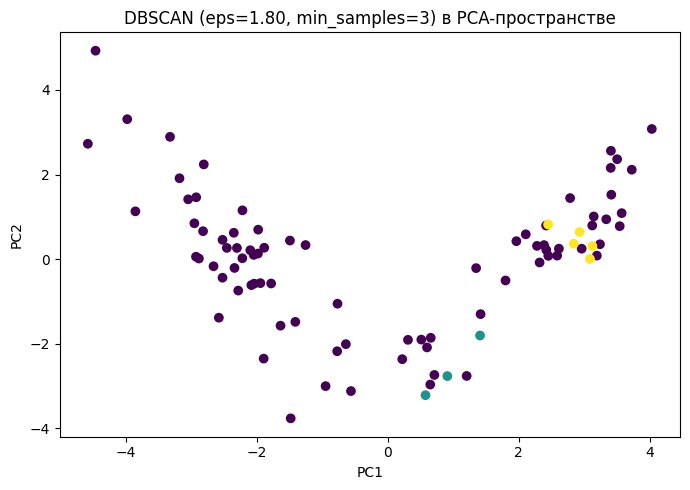

In [38]:
# PCA уже посчитан ранее: X_pca
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_km)
plt.title(f"KMeans (k={k}) в PCA-пространстве")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db)
plt.title(f"DBSCAN (eps={best_eps:.2f}, min_samples={best_ms}) в PCA-пространстве")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


### Анализ PCA-визуализации кластеров

PCA переводит данные в 2D/3D так, чтобы сохранить максимум дисперсии. На графике:

- **Хорошо разделённые облака** → кластеры интерпретируемы.  
- **Сильное перекрытие** → структура слабая или нужны другие методы/признаки.  
- **Шум DBSCAN** (`-1`) часто виден как разреженные точки вокруг плотных областей.

**Сравнение на PCA:**  
- K-means обычно делит пространство «границами Вороного» (линейно/по расстоянию до центров),  
- DBSCAN выделяет **плотные области**, поэтому на PCA часто лучше показывает «ядра» и выбросы.


## 11. Интерпретация кластеров

Для содержательной интерпретации сравним средние значения признаков по кластерам.
Для K-means удобно использовать центры кластеров; для DBSCAN — средние по кластерам (исключая шум).

In [39]:
# KMeans: средние (в исходных единицах)
km_profile = df.assign(cluster=labels_km).groupby("cluster")[num_cols].mean()
display(km_profile)

# DBSCAN: средние по кластерам (без шума)
mask = labels_db != -1
db_profile = df.loc[mask].assign(cluster=labels_db[mask]).groupby("cluster")[num_cols].mean()
display(db_profile)


,Na2O,MgO,Al2O3,SiO2,K2O,CaO,TiO2,Fe2O3,MnO,CuO,ZnO,PbO2,Rb2O,SrO,Y2O3,ZrO2,P2O5
cluster,,,,,,,,,,,,,,,,,
0,0.360286,0.335143,22.526000,68.197714,5.174571,0.210000,0.138286,2.058571,367.714286,30.000000,97.428571,49.428571,345.142857,13.428571,54.000000,195.428571,95.142857
1,0.545283,0.492830,14.116038,70.899811,4.848868,6.788113,0.076792,1.233396,1116.603774,31.509434,93.962264,31.320755,287.547170,371.132075,35.660377,112.452830,669.245283


,Na2O,MgO,Al2O3,SiO2,K2O,CaO,TiO2,Fe2O3,MnO,CuO,ZnO,PbO2,Rb2O,SrO,Y2O3,ZrO2,P2O5
cluster,,,,,,,,,,,,,,,,,
0,0.603333,0.343333,19.873333,71.956667,4.70,0.366667,0.066667,1.086667,453.333333,16.666667,76.666667,20.0,416.666667,0.0,40.0,86.666667,110.0
1,0.288000,0.272000,23.130000,67.406000,5.56,0.210000,0.120000,2.014000,356.000000,14.000000,106.000000,46.0,346.000000,6.0,60.0,164.000000,74.0


### Интерпретация профилей кластеров (что писать в выводах)

Для каждого кластера смотрим:

- **Какие признаки выше среднего по датасету**, какие ниже.
- **Какие признаки сильнее всего отличают кластеры** (наибольший разрыв между кластерами).
- **Согласованность с `Part`** (если `Part` отражает реальные типы/части образцов):  
  высокая согласованность → кластеры отражают «реальные» группы, низкая → либо `Part` не связан с химией, либо структура данных слабая.

Рекомендуемая формулировка вывода по кластерам:
- *Кластер 0:* повышены A, B; понижены C → можно трактовать как «богатые компонентом A/B».  
- *Кластер 1:* наоборот, высок C → «другая рецептура/сырьё».  
- *Шум (DBSCAN):* редкие/аномальные составы или измерительные артефакты.



# 12. Сравнение методов кластеризации (исправлено) ✅

Ниже приведён **устойчивый к перезапуску ядра** блок сравнения K-means и DBSCAN:
- автоматически использует `X_std` или `X_scaled`, а если их нет — стандартизирует `X`;
- корректно считает метрики для DBSCAN **без шума** (`label = -1`);
- строит сравнивающие графики: bar chart метрик, boxplot компактности, PCA-визуализация, доля шума.


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA


In [41]:
# --- Подготовка признаков (X_used) ---
if "X_std" in globals():
    X_used = X_std
    print("Используется X_std")
elif "X_scaled" in globals():
    X_used = X_scaled
    print("Используется X_scaled")
elif "X" in globals():
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_used = scaler.fit_transform(X)
    print("Выполнено StandardScaler: X -> X_used")
else:
    raise NameError("Не найдены признаки. Нужны X (сырые) или X_std/X_scaled (масштабированные).")

# Если DataFrame -> numpy
if hasattr(X_used, "values"):
    X_used = X_used.values

# --- Подготовка меток ---
if "labels_km" in globals():
    labels_kmeans = labels_km
    print("Используются метки K-means: labels_km")
elif "labels_kmeans" in globals():
    labels_kmeans = labels_kmeans
    print("Используются метки K-means: labels_kmeans")
else:
    raise NameError("Не найдены метки K-means (labels_km или labels_kmeans).")

if "labels_db" in globals():
    labels_dbscan = labels_db
    print("Используются метки DBSCAN: labels_db")
elif "labels_dbscan" in globals():
    labels_dbscan = labels_dbscan
    print("Используются метки DBSCAN: labels_dbscan")
else:
    raise NameError("Не найдены метки DBSCAN (labels_db или labels_dbscan).")

labels_kmeans = np.asarray(labels_kmeans)
labels_dbscan = np.asarray(labels_dbscan)


Используется X_std
Используются метки K-means: labels_km
Используются метки DBSCAN: labels_db


In [42]:
def internal_metrics(X, labels):
    labels = np.asarray(labels)

    # Для DBSCAN убираем шум
    if -1 in labels:
        mask = labels != -1
        X = X[mask]
        labels = labels[mask]

    if len(np.unique(labels)) < 2 or len(labels) < 3:
        return np.nan, np.nan, np.nan

    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    chi = calinski_harabasz_score(X, labels)
    return sil, dbi, chi

sil_k, db_k, ch_k = internal_metrics(X_used, labels_kmeans)
sil_d, db_d, ch_d = internal_metrics(X_used, labels_dbscan)

noise_share = float(np.mean(labels_dbscan == -1))

metrics_df = pd.DataFrame({
    "Метод": ["K-means", "DBSCAN"],
    "Silhouette (↑)": [sil_k, sil_d],
    "Davies–Bouldin (↓)": [db_k, db_d],
    "Calinski–Harabasz (↑)": [ch_k, ch_d],
    "Доля шума": [0.0, noise_share]
})

metrics_df


,Метод,Silhouette (↑),Davies–Bouldin (↓),Calinski–Harabasz (↑),Доля шума
0,K-means,0.273369,1.383832,37.246712,0.000000
1,DBSCAN,0.521370,0.623863,13.427632,0.909091


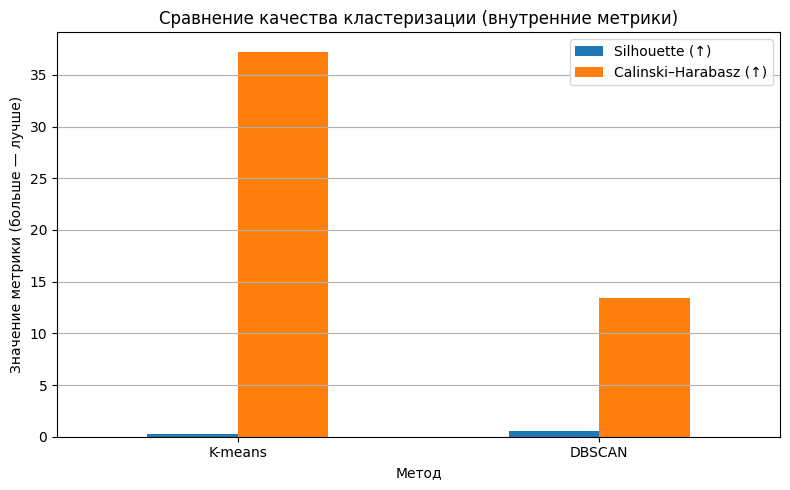

In [43]:
metrics_df.set_index("Метод")[["Silhouette (↑)", "Calinski–Harabasz (↑)"]].plot(
    kind="bar", figsize=(8, 5)
)
plt.title("Сравнение качества кластеризации (внутренние метрики)")
plt.ylabel("Значение метрики (больше — лучше)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


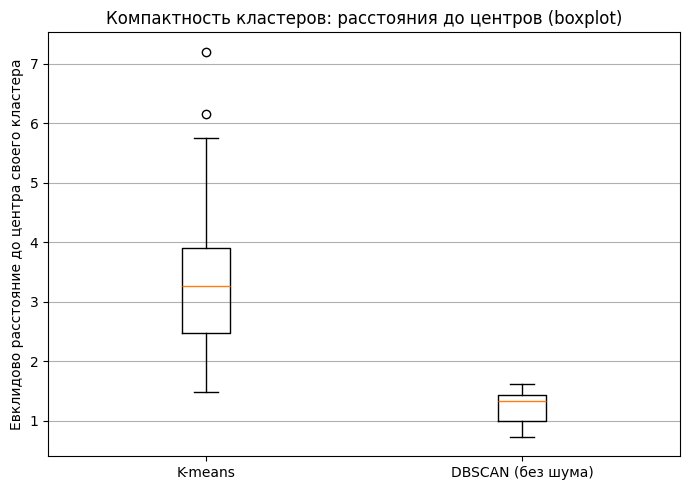

In [44]:
def dist_to_center(X, labels):
    d = []
    for c in np.unique(labels):
        if c == -1:
            continue
        Xc = X[labels == c]
        if len(Xc) == 0:
            continue
        center = Xc.mean(axis=0)
        d.extend(np.linalg.norm(Xc - center, axis=1))
    return np.asarray(d, dtype=float)

d_kmeans = dist_to_center(X_used, labels_kmeans)
d_dbscan = dist_to_center(X_used, labels_dbscan)

plt.figure(figsize=(7, 5))
plt.boxplot([d_kmeans, d_dbscan], labels=["K-means", "DBSCAN (без шума)"], showfliers=True)
plt.title("Компактность кластеров: расстояния до центров (boxplot)")
plt.ylabel("Евклидово расстояние до центра своего кластера")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


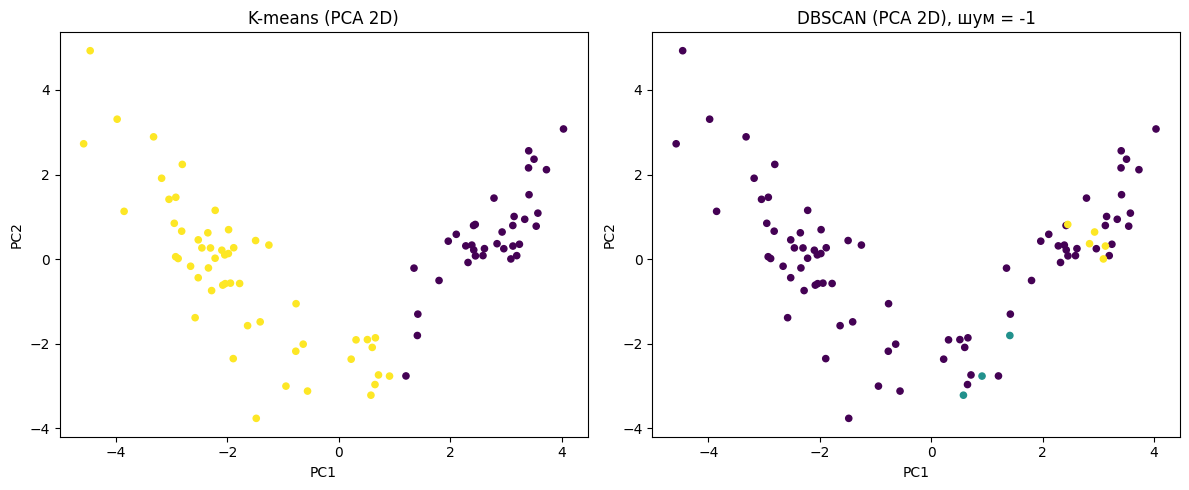

In [45]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_used)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, s=20)
ax[0].set_title("K-means (PCA 2D)")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan, s=20)
ax[1].set_title("DBSCAN (PCA 2D), шум = -1")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()


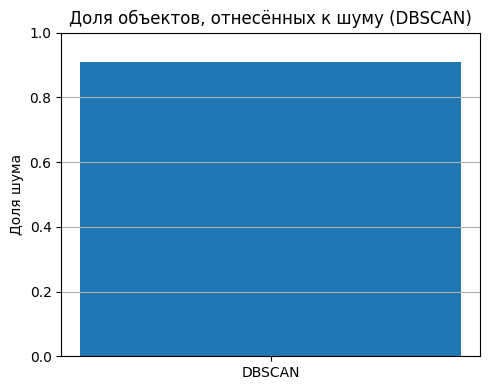

In [46]:
plt.figure(figsize=(5, 4))
plt.bar(["DBSCAN"], [noise_share])
plt.ylim(0, 1)
plt.title("Доля объектов, отнесённых к шуму (DBSCAN)")
plt.ylabel("Доля шума")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Сравнение методов кластеризации: K-means vs DBSCAN

**Сравнение по внутренним метрикам (таблица и bar chart).**  
По значениям Silhouette, Calinski–Harabasz и (инвертированного) Davies–Bouldin можно оценить:
- **разделимость кластеров** (Silhouette: чем больше, тем лучше),
- **компактность и отделимость** (CH: чем больше, тем лучше),
- **отношение внутрикластерной компактности к межкластерной разделимости** (DBI: чем меньше, тем лучше).

Если у K-means выше Silhouette и CH, а DBI ниже, это означает, что K-means формирует более компактные и лучше разделимые группы в данном признаковом пространстве.  
Если DBSCAN показывает сравнимые или лучшие значения, это указывает на наличие кластеров сложной формы/разной плотности, где метод плотности оказывается предпочтительнее.

---

**Сравнение компактности по boxplot («ящики с усами»).**  
На boxplot показано распределение расстояний от объектов до центра своего кластера:
- Более низкая медиана и более узкий интерквартильный размах означают **более компактные кластеры**.
- Наличие длинных «усов» и большого числа выбросов указывает на **неоднородность** кластеров либо влияние аномалий.

Если для K-means boxplot ниже и уже, значит кластеры K-means более компактны (что соответствует цели минимизации внутрикластерной дисперсии).  
Если у DBSCAN расстояния меньше (без учёта шума), это означает, что DBSCAN выделяет плотные ядра кластеров и «отсекает» редкие точки.

---

**Сравнение по PCA-визуализации.**  
На диаграммах PCA(2) видно, насколько хорошо кластеры отделяются в проекции:
- Если у K-means кластеры визуально разделимы и имеют примерно «сферическую» структуру — это подтверждает корректность предпосылок метода.
- Если у DBSCAN хорошо видны плотные области и одновременно присутствуют точки шума (метка -1) — это подтверждает способность метода выявлять аномалии и кластеры сложной формы.

---

**Доля шума DBSCAN (отдельный график).**  
График доли объектов, помеченных как шум, показывает устойчивость DBSCAN:
- Небольшая доля шума означает, что большинство объектов удаётся отнести к кластерам.
- Большая доля шума может говорить о слишком строгих параметрах (малый eps или большой min_samples) либо о высокой разреженности данных.

---

### Итоговый вывод
- **K-means** предпочтителен, если кластеры близки к компактным и примерно одинаковым по масштабу (что часто подтверждается высокой компактностью и более стабильными метриками).  
- **DBSCAN** предпочтителен, если в данных присутствуют **выбросы/шум**, а кластеры могут иметь **сложную форму** и **неравномерную плотность** (что видно по шуму и плотным ядрам на PCA).

Таким образом, выбор «лучшего» метода определяется тем, что важнее для задачи: стабильная сегментация всех объектов (K-means) или выделение плотных групп с обнаружением аномалий (DBSCAN).
